# 02: VAEによるAnonymizerの学習

`01_make_dataset.ipynb` で抽出したArcFace顔ベクトルを用いて，`VAEAnonymizer` を学習する．

学習の目的関数は，再構成誤差(MSE)とKLダイバージェンス(KLD)の重み付き和である．

$$
\mathcal{L} = \mathrm{MSE}(\hat{\mathbf{v}}, \mathbf{v}) + \alpha \cdot \mathrm{KLD}(\boldsymbol{\mu}, \boldsymbol{\sigma})
$$

ここで $\mathbf{v}$ が入力の顔ベクトル，$\hat{\mathbf{v}}$ が再構成後の顔ベクトル，
$\boldsymbol{\mu}, \boldsymbol{\sigma}$ がエンコーダの出力(潜在変数の平均・標準偏差)，
$\alpha$ がKLDの重みである．


In [1]:
import os
import sys

# notebooks/ から見て1階層上がリポジトリルート
REPO_ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
os.chdir(REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_jp_font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_jp_font_path):
    fm.fontManager.addfont(_jp_font_path)
    plt.rcParams["font.family"] = "Noto Sans CJK JP"
    plt.rcParams["axes.unicode_minus"] = False


In [2]:
import copy
import json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from identity_anonymizer.anonymizers import VAEAnonymizer
from identity_anonymizer.utils.seed import set_seed


In [3]:
def load_embedding_dataloaders(processed_dir: str, batch_size: int, seed: int = 0):
    """
    抽出済みのArcFace顔ベクトルから学習用・検証用のデータローダーを作成する．

    引数:
        processed_dir (str): `train_source_embeds.npy`, `test_source_embeds.npy` を
            格納したディレクトリ．
        batch_size (int): バッチサイズ．
        seed (int): データのシャッフルを決定論的にするためのseed値．
    戻り値:
        train_loader (torch.utils.data.DataLoader): 学習用データローダー．
        test_loader (torch.utils.data.DataLoader): 検証用データローダー．
    """
    train_embeds = np.load(f"{processed_dir}/train_source_embeds.npy")
    test_embeds = np.load(f"{processed_dir}/test_source_embeds.npy")

    set_seed(seed=seed)
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_dataset = torch.tensor(train_embeds, dtype=torch.float32)
    test_dataset = torch.tensor(test_embeds, dtype=torch.float32)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


In [4]:
def train_vae_anonymizer(
    target_weight_path: str,
    processed_dir: str = "data/processed",
    epochs: int = 25,
    batch_size: int = 8,
    alpha: float = 1.0,
    latent_dim: int = 128,
    seed: int = 0,
    verbose: bool = True,
):
    """
    VAEAnonymizerを学習し，学習済み重みを保存する．

    引数:
        target_weight_path (str): 学習済み重みの保存先パス．
        processed_dir (str): 学習用・検証用の顔ベクトル(`.npy`)を格納したディレクトリ．
        epochs (int): エポック数．
        batch_size (int): バッチサイズ．
        alpha (float): KLDの重み．
        latent_dim (int): 潜在空間の次元数．
        seed (int): 再現性確保のためのseed値．
        verbose (bool): 学習の進捗をtqdmで表示するかどうか．
    戻り値:
        history (dict): 各エポックの学習/検証の損失を記録した辞書．
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader, test_loader = load_embedding_dataloaders(processed_dir, batch_size, seed=seed)

    model = VAEAnonymizer(latent_dim=latent_dim, seed=seed).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    def loss_function(y, t, mu, logvar):
        mse = nn.MSELoss(reduction="mean")(y, t)
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / (y.size(0) * model.embedding_dim)
        return mse, alpha * kld

    def iteration(batch, optimizer):
        batch = batch.to(device)
        if optimizer is not None:
            optimizer.zero_grad()
            y, mu, logvar = model(batch, noise_level=1.0)
            mse, kld = loss_function(y, batch, mu, logvar)
            loss = mse + kld
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                y, mu, logvar = model(batch, noise_level=1.0)
                mse, kld = loss_function(y, batch, mu, logvar)
                loss = mse + kld
        cossim = F.cosine_similarity(y, batch, dim=1).mean().item()
        return {"loss": loss.item(), "mse": mse.item(), "kld": kld.item(), "cosine_similarity": cossim}

    def epoch(dataloader, optimizer):
        sums = {"loss": 0.0, "mse": 0.0, "kld": 0.0, "cosine_similarity": 0.0}
        num_samples = 0
        pb = tqdm(dataloader, leave=False) if verbose else dataloader
        for batch in pb:
            metrics = iteration(batch, optimizer)
            for k, v in metrics.items():
                sums[k] += v * len(batch)
            num_samples += len(batch)
            if verbose:
                pb.set_postfix({k: v / num_samples for k, v in sums.items()})
        return {k: v / num_samples for k, v in sums.items()}

    history = {f"train_{k}": [] for k in ["loss", "mse", "kld", "cosine_similarity"]}
    history.update({f"test_{k}": [] for k in ["loss", "mse", "kld", "cosine_similarity"]})

    best_test_cossim = -1.0
    os.makedirs(os.path.dirname(target_weight_path) or ".", exist_ok=True)

    for i in range(epochs + 1):
        if i == 0:
            model.eval()
            train_metrics = epoch(train_loader, optimizer=None)
        else:
            model.train()
            train_metrics = epoch(train_loader, optimizer=optimizer)

        model.eval()
        test_metrics = epoch(test_loader, optimizer=None)

        for k, v in train_metrics.items():
            history[f"train_{k}"].append(v)
        for k, v in test_metrics.items():
            history[f"test_{k}"].append(v)

        if verbose:
            print(f"epoch {i}: train_loss={train_metrics['loss']:.4f}, test_loss={test_metrics['loss']:.4f}, "
                  f"test_cossim={test_metrics['cosine_similarity']:.4f}")

        if test_metrics["cosine_similarity"] > best_test_cossim:
            best_test_cossim = test_metrics["cosine_similarity"]
            torch.save(model.state_dict(), target_weight_path)

    return history


In [5]:
EPOCHS = 25
BATCH_SIZE = 8
ALPHA = 1.0
LATENT_DIM = 128

TARGET_WEIGHT_PATH = "weights/anonymizers/vae/vae_512_128_demo.pt"

history = train_vae_anonymizer(
    target_weight_path=TARGET_WEIGHT_PATH,
    processed_dir="data/processed",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    alpha=ALPHA,
    latent_dim=LATENT_DIM,
    seed=0,
    verbose=True,
)


epoch 0: train_loss=1.3692, test_loss=1.3716, test_cossim=0.0003


epoch 1: train_loss=1.0794, test_loss=0.9706, test_cossim=0.3147


epoch 2: train_loss=0.9001, test_loss=0.8549, test_cossim=0.4864


epoch 3: train_loss=0.8219, test_loss=0.8060, test_cossim=0.5498


epoch 4: train_loss=0.7819, test_loss=0.7741, test_cossim=0.5899


...

epoch 21: train_loss=0.6534, test_loss=0.6616, test_cossim=0.7225


epoch 22: train_loss=0.6521, test_loss=0.6596, test_cossim=0.7240


epoch 23: train_loss=0.6501, test_loss=0.6573, test_cossim=0.7262


epoch 24: train_loss=0.6483, test_loss=0.6556, test_cossim=0.7284


epoch 25: train_loss=0.6474, test_loss=0.6547, test_cossim=0.7292


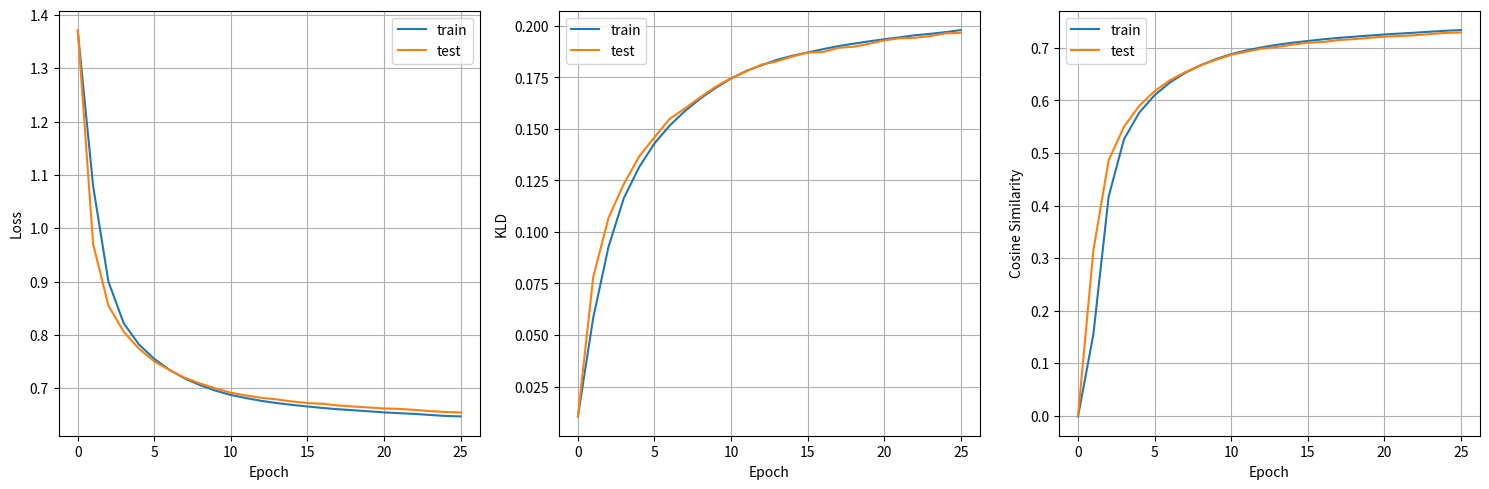

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(history["train_kld"], label="train")
axes[1].plot(history["test_kld"], label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KLD")
axes[1].legend()
axes[1].grid()

axes[2].plot(history["train_cosine_similarity"], label="train")
axes[2].plot(history["test_cosine_similarity"], label="test")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Cosine Similarity")
axes[2].legend()
axes[2].grid()

fig.tight_layout()
fig.savefig("weights/anonymizers/vae/vae_512_128_demo_history.png")
plt.show()


学習済みの重みは `weights/anonymizers/vae/vae_512_128_demo.pt` に保存される．
`03_inference_image.ipynb` 以降で使用している `weights/anonymizers/vae/vae_512_128.pt` は，
UTKFace全件(23,088枚)を用いて同一の手順で学習したものである．
